# Plane-Parallel Slab — High-Level Interface

Using the new `LineRT` class with `SlabSource` and automatic `run()`.
No manual I/O, no par-file templating, no subprocess calls.

The notebook is ~3× shorter than the low-level version and ~2× shorter than the old high-level version.

In [1]:
%matplotlib inline
import sys, os
import numpy as np
import matplotlib.pyplot as plt

_SCRATCH = os.path.expanduser('~/scratch/line_rt')
sys.path.insert(0, _SCRATCH)

_PROJECT = os.path.expanduser('~/Seafile/seafile_sync/code/line_rt_pipeline')
sys.path.insert(0, _PROJECT)

from linert import LineRT, SlabSource, CycleResult, EscapedPhotons, Result
from molecular.lamda_format import load_species_transition

print('All imports successful.')

All imports successful.


## 1. One-liner setup

Slab in x: [-5, 5] AU, thin in y/z.
CO J=1→0 transition (115.271 GHz) loaded from LAMDA data.
n_total computed to give τ₀ = 100 line-centre optical depth → each photon random-walks ~τ₀² ≈ 10⁴ scatters.
Species-based opacity (Mode 2) with iterative population update.

In [2]:
AU_cm   = 1.49598e13
slab_cm = 10 * AU_cm
tau0    = 100.0
n_photon = 50000

_CO_FILE = os.path.expanduser('~/Seafile/seafile_sync/code/line_rt_pipeline/molecular/embedded/co.dat')
species, transition = load_species_transition(_CO_FILE, freq_GHz=115.271202)
tidx = species.find_transition_idx(transition)
sigma0 = species.cross_section(tidx, b_param=1e5)
n_total = tau0 / (slab_cm * sigma0)

rt = LineRT(
    source=SlabSource(x0=-5, n_photon=n_photon),
    x_min=(-5.0, 0.0, 0.0),
    x_max=( 5.0, 0.2, 0.2),
    n_cell=(64, 2, 2),
    species=species,
    n_total=n_total,
    transition=transition,
    b_thermal=1e5,
    temperature=10.0,
    n_photon=n_photon,
    n_step=10000,
    n_scat=100000,
    ph_mode=1,
    n_cycles=3,
    mol_mass=28.0,
    work_dir='/tmp/linert_hl_nb',
)
print(f'LineRT ready: {rt.n_tot} cells, work_dir={rt.work_dir}')

LineRT ready: 256 cells, work_dir=/tmp/linert_hl_nb


## 2. Run — single call

`rt.run()` handles field writing, photon generation, par-file creation,
Kratos execution, and output reading — all encapsulated.

In [3]:
%%time
result = rt.run(n_cycles=3)
print(f'\nDone: {len(result)} cycles.')

=== Cycle 0 / 3 ===
Wrote fields: /tmp/linert_hl_nb/fields_cycle0.bin
Wrote photons: /tmp/linert_hl_nb/photons_cycle0.bin (50000 photons, 11 cols)
  exc_flux_max=1.8901e-04, flx_max=5.5819e+01, exc_max=3.1491e-04, n_esc=50000, t=0.6s
=== Cycle 1 / 3 ===
Wrote fields: /tmp/linert_hl_nb/fields_cycle1.bin
Wrote photons: /tmp/linert_hl_nb/photons_cycle1.bin (50000 photons, 11 cols)
  exc_flux_max=2.0405e-04, flx_max=6.0185e+01, exc_max=3.3954e-04, n_esc=50000, t=0.6s
=== Cycle 2 / 3 ===
Wrote fields: /tmp/linert_hl_nb/fields_cycle2.bin
Wrote photons: /tmp/linert_hl_nb/photons_cycle2.bin (50000 photons, 11 cols)
  exc_flux_max=1.9416e-04, flx_max=5.6891e+01, exc_max=3.2095e-04, n_esc=50000, t=0.5s

Done: 3 cycles.
CPU times: user 14.1 ms, sys: 11 ms, total: 25.1 ms
Wall time: 1.78 s


## 3. Results — excitation_flux / flx / exc_rate

CycleResult now includes `excitation_flux` (absorbed flux), `flx` (effective flux),
and `exc_rate` (photon excitation rate per cell).

In [5]:
for cr in result:
    print(f'Cycle {cr.cycle}: '
          f'exc_flux_max={cr.excitation_flux.max():.4e}, '
          f'flx_max={cr.flx.max():.4e}, '
          f'exc_max={cr.exc_rate.max():.4e}, '
          f'n_esc={len(cr.photons):,}, '
          f't={cr.elapsed:.1f}s')

AttributeError: 'CycleResult' object has no attribute 'fab'

## 4. Emergent spectrum

Two views:
- Weighted histogram of escaped photon velocities
- Synthesised spectrum from photon Gaussians via `photons.synthesize_spectrum()`

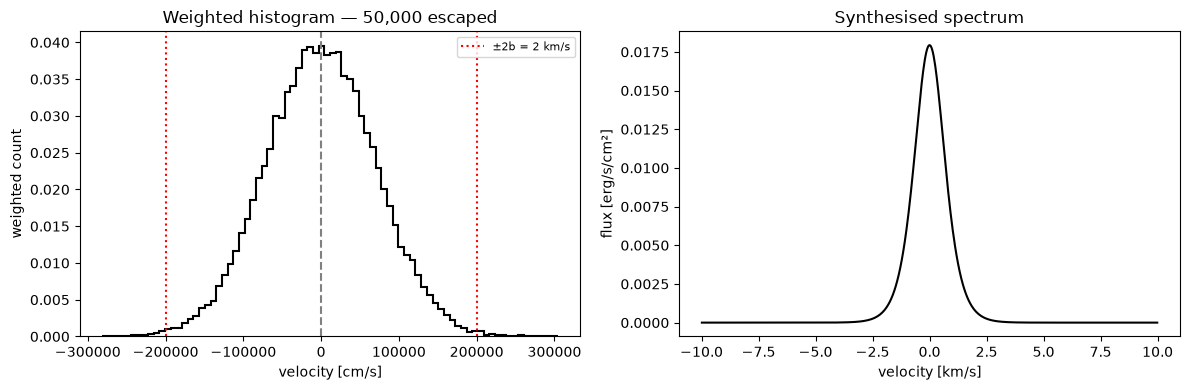

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ph = result[-1].photons

if len(ph) > 0:
    b = 1e5  # cm/s
    ax1.hist(ph.velocity, bins=80, weights=ph.weight, histtype='step', color='k', lw=1.5)
    ax1.axvline(0, color='gray', ls='--')
    ax1.axvline(-2*b, color='r', ls=':', label=f'±2b = {2*b/1e5:.0f} km/s')
    ax1.axvline(+2*b, color='r', ls=':')
    ax1.legend(fontsize=8)
    ax1.set_title(f'Weighted histogram — {len(ph):,} escaped')
    ax1.set_xlabel('velocity [cm/s]')
    ax1.set_ylabel('weighted count')
    
    spec = ph.synthesize_spectrum(v_min=-1e6, v_max=1e6, n_bins=600)
    ax2.plot(spec['v_mid']*1e-5, spec['spectrum'], 'k-', lw=1.5)
    ax2.set_title('Synthesised spectrum')
    ax2.set_xlabel('velocity [km/s]')
    ax2.set_ylabel('flux [erg/s/cm²]')
else:
    ax1.text(0.5,0.5,'No escaped photons',transform=ax1.transAxes,ha='center')

fig.tight_layout()
plt.show()

## 5. Radial profiles along the slab (1D)

excitation_flux (absorbed flux), flx (effective flux), and exc_rate (photon excitation rate).

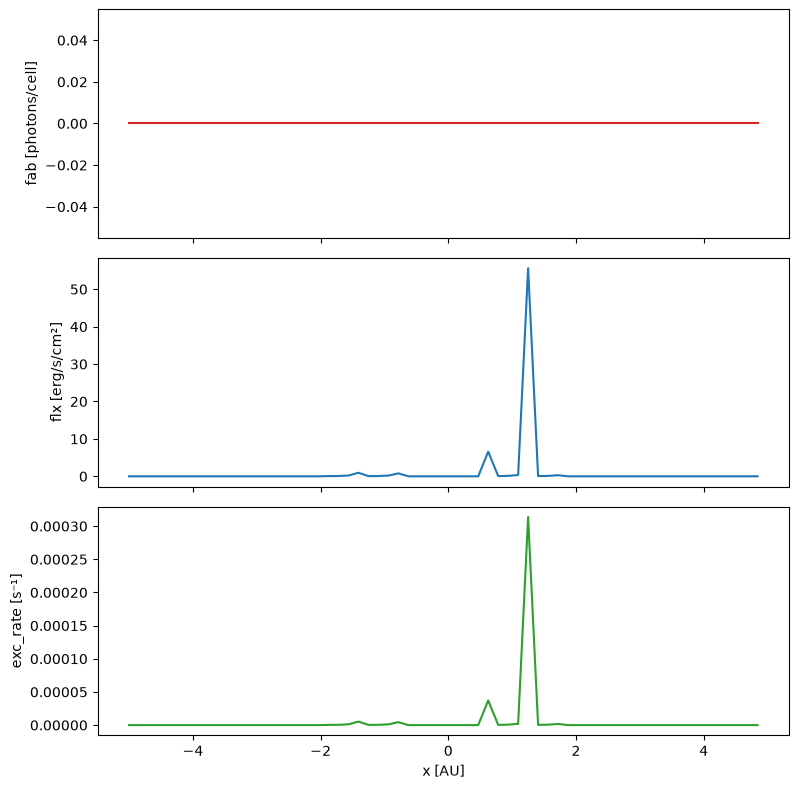

In [21]:
nc = rt.n_cell
cr = result[-1]
excitation_flux_1d  = cr.excitation_flux.reshape(int(nc[0]), int(nc[1]), int(nc[2]))[:,0,0]
flx_1d  = cr.flx.reshape(int(nc[0]), int(nc[1]), int(nc[2]))[:,0,0]
exc_1d  = cr.exc_rate.reshape(int(nc[0]), int(nc[1]), int(nc[2]))[:,0,0]
x_c = np.linspace(rt.x_min[0], rt.x_max[0], nc[0]+1)[:-1]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
ax1.plot(x_c, excitation_flux_1d, 'tab:red')
ax1.set_ylabel('excitation_flux [photons/cell]')
ax2.plot(x_c, flx_1d, 'tab:blue')
ax2.set_ylabel('flx [erg/s/cm²]')
ax3.plot(x_c, exc_1d, 'tab:green')
ax3.set_ylabel('exc_rate [s⁻¹]')
ax3.set_xlabel('x [AU]')
fig.tight_layout()
plt.show()

## 6. Convergence

Check whether excitation_flux_max, flx_max, and exc_rate_max stabilise across cycles.

In [ ]:
fig, ax1 = plt.subplots(figsize=(6, 3))
excitation_flux_max  = [c.excitation_flux.max()      for c in result.cycles]
flx_max  = [c.flx.max()      for c in result.cycles]
exc_max  = [c.exc_rate.max() for c in result.cycles]
cycles   = range(1, len(result)+1)

ax1.plot(cycles, excitation_flux_max, 'o-', color='tab:red',  label='excitation_flux max')
ax2 = ax1.twinx()
ax2.plot(cycles, flx_max, 's-', color='tab:blue', label='flx max')
ax1.plot(cycles, exc_max, '^-', color='tab:green', label='exc max')

ax1.set_xlabel('cycle')
ax1.set_ylabel('excitation_flux / exc max')
ax2.set_ylabel('flx max')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=8)
fig.tight_layout()
plt.show()

## 7. Cleanup

In [15]:
import shutil
shutil.rmtree(rt.work_dir, ignore_errors=True)
print(f'Removed {rt.work_dir}')

Removed /tmp/linert_hl_nb
